# 01 - Exploración inicial del dataset Cora

En este notebook vamos a cargar el conjunto de datos Cora, analizar su estructura básica y construir el grafo de citaciones usando NetworkX.

Los objetivos iniciales son:

- Leer los archivos `cora.content` y `cora.cites`.
- Contar el número de nodos.
- Contar el número de aristas.
- Ver las clases disponibles.
- Construir el grafo con NetworkX.

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
contenido = pd.read_csv("../data/raw/cora.content", sep="\t", header=None)
contenido.head()
# la columna 0 se corresponde al id del nodo, las columnas 1 a 1433 corresponden al los atriibutos 
# de palabra y la columna 1434 se corresponde a la clase a la que pertenece cada nodo

,0,1,2,3,4,5,6,7,8,9,...,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [4]:
citas = pd.read_csv("../data/raw/cora.cites", sep="\t", header=None)
citas.head()
# primera columna es el articulo citado y la segunda el que lo cita 

,0,1
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


In [5]:
contenido.shape

(2708, 1435)

In [6]:
citas.shape

(5429, 2)

## Renombrado de columnas

A continuación, vamos a cambiar el nombre de las columnas del dataset para facilitar la comprensión y el trabajo con los datos.

El archivo `cora.content` no incluye nombres de columnas, por lo que inicialmente aparecen numeradas automáticamente. Para trabajar de forma más clara, asignaremos nombres descriptivos:

- `articulo_id`: identificador del artículo.
- `palabra_0`, `palabra_1`, ..., `palabra_1432`: atributos que indican la presencia o ausencia de palabras en el artículo.
- `clase`: categoría temática del artículo.

También renombraremos las columnas del archivo `cora.cites` para identificar claramente qué artículo cita y qué artículo es citado.

In [7]:
num_features = contenido.shape[1] - 2 # nos da el numero de columnas de las palabras

columnas = ["articulo_id"] + [f"palabra_{i}" for i in range(num_features)] + ["clase"]

contenido.columns = columnas

contenido.head()

,articulo_id,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,...,palabra_1424,palabra_1425,palabra_1426,palabra_1427,palabra_1428,palabra_1429,palabra_1430,palabra_1431,palabra_1432,clase
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [8]:
citas.columns = ["articulo_citado_id", "articulo_citante_id"]

citas.head()

,articulo_citado_id,articulo_citante_id
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


## Tamaño del conjunto de datos

En esta sección analizamos el número de artículos, palabras y relaciones presentes en el conjunto de datos.

In [9]:
print("Número de artículos:", contenido.shape[0])
print("Número de características de palabras:", contenido.shape[1] - 2)
print("Número de relaciones de citación:", citas.shape[0])

Número de artículos: 2708
Número de características de palabras: 1433
Número de relaciones de citación: 5429


A continuación, mostramos el número, tipo de clases y su distribución.

In [10]:
print("Número de clases:", contenido["clase"].nunique())
print("\nClases presentes:")
print(contenido["clase"].unique())

Número de clases: 7

Clases presentes:
['Neural_Networks' 'Rule_Learning' 'Reinforcement_Learning'
 'Probabilistic_Methods' 'Theory' 'Genetic_Algorithms' 'Case_Based']


In [11]:
class_counts = contenido["clase"].value_counts()

print(class_counts)

clase
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64


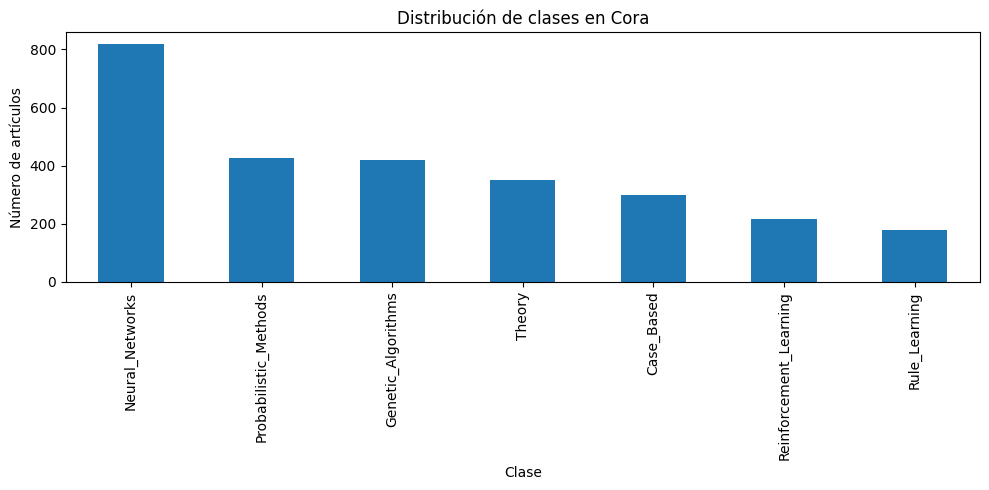

In [12]:
plt.figure(figsize=(10,5))
class_counts.plot(kind="bar")
plt.title("Distribución de clases en Cora")
plt.xlabel("Clase")
plt.ylabel("Número de artículos")
plt.tight_layout()
plt.show()

Vamos a comprobar posibles valores nulos

In [13]:
print("Nulos en contenido:")
print(contenido.isnull().sum().sum())

print("Nulos en citas:")
print(citas.isnull().sum().sum())

Nulos en contenido:
0
Nulos en citas:
0


En este caso no hay en ninguno de los dos.

In [14]:
print("Duplicados en contenido:")
print(contenido.duplicated().sum())

print("Duplicados en citas:")
print(citas.duplicated().sum())

Duplicados en contenido:
0
Duplicados en citas:
0


Tampoco hay duplicados.

In [15]:
articulos_citados = set(citas["articulo_citado_id"])
articulos_citantes = set(citas["articulo_citante_id"])

articulos_en_citas = articulos_citados.union(articulos_citantes)

print("Artículos presentes en relaciones:", len(articulos_en_citas))
print("Artículos totales:", contenido.shape[0])

Artículos presentes en relaciones: 2708
Artículos totales: 2708


El número de artículos distintos que aparecen en las citas es 2708, por tanto, no hay nodos aislados.

## Conclusiones de la exploración

El dataset Cora contiene 2708 artículos científicos pertenecientes a 7 categorías distintas (Neural_Networks, Probabilistic_Methods, Genetic_Algorithms,Theory, Case_Based, Reinforcement_Learning y Rule_Learning).

Cada artículo está representado mediante 1433 atributos binarios que indican la presencia o ausencia de determinadas palabras.

Las relaciones de citación permiten modelar el conjunto como un grafo donde los nodos representan artículos y las aristas representan citas entre ellos. En total hay 5429 relaciones de citación.

Tras la exploración inicial no se han detectado valores perdidos ni problemas significativos de calidad de datos.

#### Algunas comprobaciones con palabras

In [16]:
palabras_activas = contenido.iloc[:, 1:-1].sum(axis=1)

print(palabras_activas.describe())

count    2708.000000
mean       18.174298
std         5.758010
min         1.000000
25%        17.000000
50%        20.000000
75%        22.000000
max        30.000000
dtype: float64


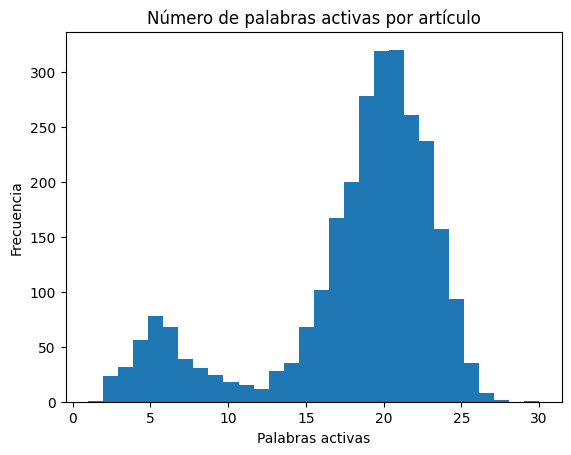

In [17]:
plt.hist(palabras_activas, bins=30)
plt.title("Número de palabras activas por artículo")
plt.xlabel("Palabras activas")
plt.ylabel("Frecuencia")
plt.show()

# Construcción del grafo

A partir del fichero de citaciones se construye un grafo dirigido donde:

- Cada nodo representa un artículo científico.
- Cada arista representa una relación de citación.

In [18]:
G_directed = nx.from_pandas_edgelist(
    citas,
    source="articulo_citante_id",
    target="articulo_citado_id",
    create_using=nx.DiGraph()
)

Comprobamos el número de nodos y aristas.

In [19]:
print("Número de nodos:", G_directed.number_of_nodes())
print("Número de aristas:", G_directed.number_of_edges())

Número de nodos: 2708
Número de aristas: 5429


In [20]:
nodos_sin_relaciones = set(contenido["articulo_id"]) - set(G_directed.nodes())

print("Nodos sin relaciones:", len(nodos_sin_relaciones))

Nodos sin relaciones: 0


Añadimos la clase a cada nodo, pues es la variable que queremos predecir.

In [21]:
for _, fila in contenido.iterrows():

    articulo = fila["articulo_id"]

    G_directed.nodes[articulo]["clase"] = fila["clase"]

In [22]:
primer_nodo = list(G_directed.nodes())[0]

print(G_directed.nodes[primer_nodo])

{'clase': 'Genetic_Algorithms'}


Vamos a crear la versión no dirigida del grafo pues funciona mejor para la mayoría de métricas relacionales.

In [23]:
G = G_directed.to_undirected()

## Estadísticas básicas del grafo

In [24]:
print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())
print("Número de componentes conexas:",
      nx.number_connected_components(G))
print("Densidad:",
      nx.density(G))
grado_medio = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Grado medio:", grado_medio)

Número de nodos: 2708
Número de aristas: 5278
Número de componentes conexas: 78
Densidad: 0.0014399999126942077
Grado medio: 3.8980797636632203


Vamos a mostrar una pequeña subred del grafo pues se trata de un gran grafo.

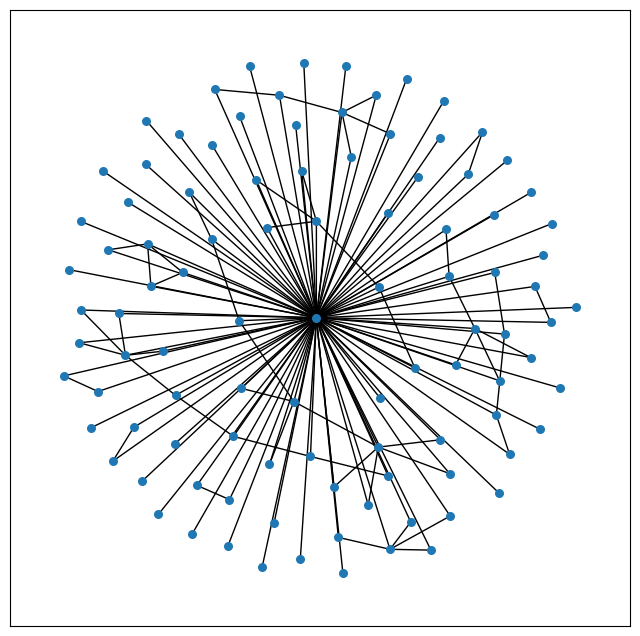

In [29]:
subgrafo = G.subgraph(list(G.nodes())[:100])

plt.figure(figsize=(8,8))
nx.draw_networkx(subgrafo,
                 node_size=30,
                 with_labels=False)
plt.show()

## Conclusiones de la construcción del grafo.

Se ha construido correctamente el grafo de citaciones del conjunto Cora.

El grafo contiene 2708 nodos, correspondientes a artículos científicos, y 5429 aristas, correspondientes a relaciones de citación.

Además, se ha incorporado la clase temática de cada artículo como atributo de nodo, lo que permitirá posteriormente realizar tareas de clasificación de nodos utilizando métricas relacionales extraídas del grafo.